In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

# load your dataset
df = pd.read_csv("/content/drive/MyDrive/tree_trait_matrix.csv")

# count non-null values in each column
non_null_counts = df.notna().sum()

# get the column with the maximum filled values
most_filled_column = non_null_counts.idxmax()
max_count = non_null_counts.max()

print("Most filled column:", most_filled_column)
print("Number of non-null values:", max_count)

Most filled column: SpeciesName
Number of non-null values: 345845


In [ ]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/tree_trait_matrix.csv")

# count non-null values per column
non_null_counts = df.notna().sum()

# get top 10 most filled columns
top_10 = non_null_counts.sort_values(ascending=False).head(10)

print(top_10)

SpeciesName                     345845
Plant growth form               326139
Plant woodiness                  93427
Plant lifespan (longevity)       31254
Fruit type                       15402
Flower sex                       14761
Flower color                     11308
Wood growth ring distinction      5286
Plant human usage types           4472
Seed germination requirement      3810
dtype: int64


In [ ]:
total_rows = len(df)

top_10_percent = (non_null_counts / total_rows * 100)\
                    .sort_values(ascending=False)\
                    .head(10)

print(top_10_percent)

SpeciesName                     100.000000
Plant growth form                94.302072
Plant woodiness                  27.014125
Plant lifespan (longevity)        9.036996
Fruit type                        4.453440
Flower sex                        4.268097
Flower color                      3.269673
Wood growth ring distinction      1.528430
Plant human usage types           1.293065
Seed germination requirement      1.101650
dtype: float64


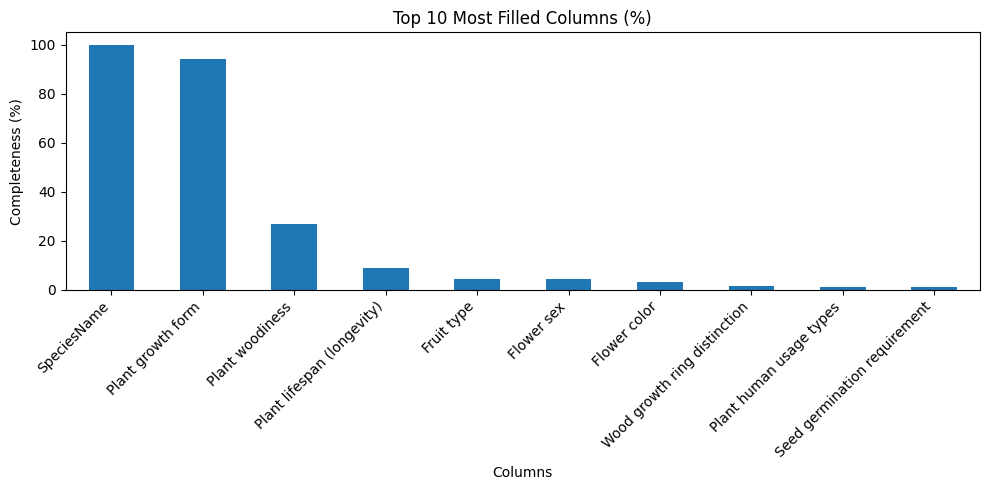

In [ ]:
import matplotlib.pyplot as plt

total_rows = len(df)

top_10_percent = (df.notna().sum() / total_rows * 100)\
                    .sort_values(ascending=False)\
                    .head(10)

plt.figure(figsize=(10, 5))
top_10_percent.plot(kind='bar')

plt.title("Top 10 Most Filled Columns (%)")
plt.ylabel("Completeness (%)")
plt.xlabel("Columns")
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

fam = pd.read_csv("/content/drive/MyDrive/flowering_plant_families.csv")
trees = pd.read_csv("/content/drive/MyDrive/global_tree_search_trees_1_9.csv")

# normalize column names
fam.columns = fam.columns.str.lower() # Changed from wfo.columns to fam.columns
trees.columns = trees.columns.str.lower()

print("Families columns:", fam.columns)
print("Trees columns:", trees.columns)

# find likely species column automatically
def find_species_col(df):
    for col in df.columns:
        if "species" in col or "scientific" in col or "taxon" in col:
            return col
    raise ValueError("No species column found")

fam_col = find_species_col(fam) # Changed from wfo to fam
trees_col = find_species_col(trees)

# standardize names
fam = fam.rename(columns={fam_col: "species"}) # Changed from wfo_col to fam_col
trees = trees.rename(columns={trees_col: "species"})

# Clean and lowercase the 'species' column after it has been standardized
fam["species"] = fam["species"].str.strip().str.lower() # Changed from wfo["scientificName"] to fam["species"]
trees["species"] = trees["species"].str.strip().str.lower() # Changed from traits["SpeciesName"] to traits["species"]

# merge without touching originals
merged = fam.merge(trees, on="species", how="left") # Changed from wfo.merge to fam.merge

merged.to_csv("fam_trees_matched.csv", index=False)

print("Done. Rows:", len(merged))

/tmp/ipykernel_5566/2926408399.py:3: DtypeWarning: Columns (10,12) have mixed types. Specify dtype option on import or set low_memory=False.
  fam = pd.read_csv("/content/drive/MyDrive/flowering_plant_families.csv")


Families columns: Index(['taxonid', 'scientificnameid', 'localid', 'scientificname', 'taxonrank',
       'parentnameusageid', 'scientificnameauthorship', 'family', 'subfamily',
       'tribe', 'subtribe', 'genus', 'subgenus', 'specificepithet',
       'infraspecificepithet', 'verbatimtaxonrank', 'nomenclaturalstatus',
       'namepublishedin', 'taxonomicstatus', 'acceptednameusageid',
       'originalnameusageid', 'nameaccordingtoid', 'taxonremarks', 'created',
       'modified', 'references', 'source', 'majorgroup', 'tplid'],
      dtype='object')
Trees columns: Index(['taxonname', 'author',
       'citation: bgci. [year accessed]. globaltreesearch online database (version 1.9). botanic gardens conservation international. richmond, uk. doi: 10.13140/rg.2.2.11951.65440 available at https://tools.bgci.org/global_tree_search.php accessed on (dd/mm/yyyy).',
       'data retrieved through globaltreesearch is subject to the bgci data agreement: https://www.bgci.org/terms-and-conditions. thi

GLOBAL TREE SEARCH PIVOT

In [ ]:
import pandas as pd

# Load datasets
fam = pd.read_csv("/content/drive/MyDrive/flowering_plant_families.csv", low_memory=False)
trees = pd.read_csv("/content/drive/MyDrive/global_tree_search_trees_1_9.csv", low_memory=False)

# Normalize column names to lowercase for consistency
fam.columns = fam.columns.str.lower()
trees.columns = trees.columns.str.lower()

# Extract only needed columns
fam = fam[["scientificname"]].copy()
trees = trees[["taxonname"]].copy()

# Clean text (VERY important)
fam["scientificname"] = fam["scientificname"].astype(str).str.strip().str.lower()
trees["taxonname"] = trees["taxonname"].astype(str).str.strip().str.lower()

# Remove duplicates BEFORE matching
fam = fam.drop_duplicates()
trees = trees.drop_duplicates()

# MATCH
matched = fam[fam["scientificname"].isin(trees["taxonname"])]

print("Flowering species total:", len(fam))
print("Tree list total:", len(trees))
print("Matched flowering trees:", len(matched))

# Save result
matched.to_csv("flowering_trees_matched.csv", index=False)

Flowering species total: 343341
Tree list total: 57596
Matched flowering trees: 53477


In [66]:
import pandas as pd

# ----------------------------
# LOAD DATA
# ----------------------------
wfo = pd.read_csv("/content/drive/MyDrive/flowering_plant_families.csv", low_memory=False)
matched = pd.read_csv("flowering_trees_matched.csv", low_memory=False)

# Standardize column names to lowercase for consistency
wfo.columns = wfo.columns.str.lower()
matched.columns = matched.columns.str.lower()

# ----------------------------
# STANDARDISE COLUMN NAMES
# ----------------------------
wfo["scientificname"] = wfo["scientificname"].astype(str).str.lower().str.strip()
matched["scientificname"] = matched["scientificname"].astype(str).str.lower().str.strip()

# ----------------------------
# REMOVE DUPLICATES IN MATCH LIST
# ----------------------------
matched = matched.drop_duplicates(subset="scientificname")

# ----------------------------
# FILTER WFO TO ONLY MATCHED TREES
# (KEEP ALL WFO COLUMNS)
# ----------------------------
filtered = wfo[wfo["scientificname"].isin(matched["scientificname"])].copy()

# ----------------------------
# REMOVE DUPLICATES IN FINAL DATASET
# ----------------------------
before = len(filtered)
filtered = filtered.drop_duplicates(subset="scientificname")
after = len(filtered)

print("Before dedup:", before)
print("After dedup (unique species):", after)

# ----------------------------
# SAVE FINAL FILE
# ----------------------------
filtered.to_csv("flowering_trees.csv", index=False)

print("Saved: flowering_trees.csv")
print("Final species count:", len(filtered))
print("Final columns retained:", len(filtered.columns))

Before dedup: 53477
After dedup (unique species): 53477
Saved: flowering_trees.csv
Final species count: 53477
Final columns retained: 29


In [67]:
matched = matched.drop_duplicates(subset="scientificname")
print("Unique matched species:", len(matched))

Unique matched species: 53477


In [68]:
print("WFO sample:")
print(trees["scientificname"].head(10))

print("\nTRY sample:")
print(try_df["speciesname"].head(10))

WFO sample:
0     euptelea pleiosperma
1       euptelea polyandra
2         bocconia arborea
3      bocconia frutescens
4     bocconia glaucifolia
5        bocconia gracilis
6     bocconia hintoniorum
7    bocconia integrifolia
8      bocconia latisepala
9       bocconia vulcanica
Name: scientificname, dtype: object

TRY sample:
0                 #Acacia baileyana F.Muell.
1                      #Acacia dealbata Link
2                   #Acacia decurrens Willd.
3            #Acacia elata A.Cunn. ex Benth.
4      #Acacia iteaphylla F.Muell. ex Benth.
5        #Acacia longifolia (Andrews) Willd.
6                  #Acacia mearnsii De Wild.
7    #Acacia podalyriifolia A.Cunn. ex G.Don
8                   #Acacia pycnantha Benth.
9       #Acacia saligna (Labill.) H.L.Wendl.
Name: speciesname, dtype: object


In [69]:
import pandas as pd
import re

trees = pd.read_csv("flowering_trees_matched.csv", low_memory=False)
try_df = pd.read_csv("/content/drive/MyDrive/tree_trait_matrix.csv", low_memory=False)

# Convert column names to lowercase for consistency
trees.columns = trees.columns.str.lower()
try_df.columns = try_df.columns.str.lower()

def clean_name(x):
    x = str(x).lower()
    x = re.sub(r"\(.*?\)", "", x)   # remove author brackets
    x = re.sub(r"\s+", " ", x)      # collapse spaces
    return x.strip()

trees["key"] = trees["scientificname"].apply(clean_name)
try_df["key"] = try_df["speciesname"].apply(clean_name)

In [70]:
merged = trees.merge(
    try_df,
    on="key",
    how="left"
)

In [71]:
print("Total rows:", len(merged))
print("Matched traits:", merged["speciesname"].notna().sum())
print("Match rate:", merged["speciesname"].notna().mean() * 100)

Total rows: 53750
Matched traits: 31186
Match rate: 58.02046511627908


In [ ]:
import pandas as pd

# --------------------------
# LOAD DATA
# --------------------------
trees = pd.read_csv("flowering_trees_matched.csv", low_memory=False)
try_df = pd.read_csv("/content/drive/MyDrive/tree_trait_matrix.csv", low_memory=False)

# Standardize column names to lowercase for consistency
trees.columns = trees.columns.str.lower()
try_df.columns = try_df.columns.str.lower()

# --------------------------
# CLEAN KEYS (CRITICAL)
# --------------------------
trees["key"] = (
    trees["scientificname"]
    .astype(str)
    .str.lower()
    .str.strip()
)

try_df["key"] = (
    try_df["speciesname"]
    .astype(str)
    .str.lower()
    .str.strip()
)

# --------------------------
# REMOVE DUPLICATES (VERY IMPORTANT)
# --------------------------
trees = trees.drop_duplicates(subset="key")
try_df = try_df.drop_duplicates(subset="key")

# --------------------------
# MERGE
# --------------------------
merged = trees.merge(
    try_df,
    on="key",
    how="left"
)

# --------------------------
# CLEAN OUTPUT
# --------------------------
merged = merged.drop(columns=["key"])

# --------------------------
# CHECK RESULT
# --------------------------
print("Final rows:", len(merged))
print("TRY matched rows:", merged["speciesname"].notna().sum())
print("Coverage %:", merged["speciesname"].notna().mean() * 100)

# --------------------------
# SAVE
# --------------------------
merged.to_csv("flowering_tree_traits_merged.csv", index=False)

Final rows: 53477
TRY matched rows: 30910
Coverage %: 57.80054976905959


In [74]:
import pandas as pd
import re

# ----------------------------
# LOAD DATA
# ----------------------------
trees = pd.read_csv("flowering_trees.csv", low_memory=False)
traits = pd.read_csv("/content/drive/MyDrive/tree_trait_matrix.csv", low_memory=False)

# Convert column names to lowercase for consistency
trees.columns = trees.columns.str.lower()
traits.columns = traits.columns.str.lower()

# ----------------------------
# CLEAN FUNCTION (CRITICAL)
# ----------------------------
def clean_name(x):
    x = str(x).lower()
    x = re.sub(r"\(.*\)", "", x)   # remove authorship in brackets
    x = re.sub(r"[^a-z\s]", "", x)  # remove special characters
    x = " ".join(x.split())         # normalize spaces
    return x.strip()

# ----------------------------
# STANDARDISE KEYS
# ----------------------------
trees["key"] = trees["scientificname"].apply(clean_name)
traits["key"] = traits["speciesname"].apply(clean_name)

# ----------------------------
# REMOVE DUPLICATES
# ----------------------------
trees = trees.drop_duplicates(subset="key")
traits = traits.drop_duplicates(subset="key")

print("Unique tree species:", len(trees))
print("Unique trait species:", len(traits))

# ----------------------------
# MERGE (LEFT JOIN = KEEP ALL 57K TREES)
# ----------------------------
merged = trees.merge(
    traits,
    on="key",
    how="left",
    suffixes=("", "_trait")
)

# ----------------------------
# DROP HELPER COLUMN
# ----------------------------
merged = merged.drop(columns=["key"])

# ----------------------------
# QUALITY CHECK
# ----------------------------
print("\nFinal rows:", len(merged))
print("Species with traits:", merged.notna().any(axis=1).sum())
print("Trait coverage %:", merged.notna().any(axis=1).mean() * 100)

# ----------------------------
# SAVE FINAL DATASET
# ----------------------------
merged.to_csv("flowering_trees_traits.csv", index=False)

print("\nSaved: flowering_trees_traits.csv")

Unique tree species: 53477
Unique trait species: 341192

Final rows: 53477
Species with traits: 53477
Trait coverage %: 100.0

Saved: flowering_trees_traits.csv


In [75]:
import pandas as pd
import random

df = pd.read_csv("flowering_trees_traits.csv", low_memory=False)

df["scientificname"] = df["scientificname"].astype(str).str.lower().str.strip()

species_set = set(df["scientificname"])

In [76]:
test_species = [
    "delonix regia",
    "bauhinia variegata",
    "jacaranda mimosifolia",
    "magnolia grandiflora",
    "cassia fistula",
    "lagerstroemia speciosa",
    "prunus serrulata",
    "erythrina variegata",
    "ficus benghalensis",
    "mangifera indica",
    "acacia nilotica",
    "syzygium cumini",
    "terminalia arjuna",
    "neem azadirachta indica",
    "plumeria rubra",
    "tecoma stans",
    "tabebuia rosea",
    "bombax ceiba",
    "salix babylonica",
    "citrus sinensis"
]

In [77]:
results = []

for sp in test_species:
    found = sp in species_set
    results.append((sp, found))

    print(f"{sp} → {'FOUND' if found else 'MISSING'}")

delonix regia → FOUND
bauhinia variegata → FOUND
jacaranda mimosifolia → FOUND
magnolia grandiflora → FOUND
cassia fistula → FOUND
lagerstroemia speciosa → FOUND
prunus serrulata → FOUND
erythrina variegata → FOUND
ficus benghalensis → FOUND
mangifera indica → FOUND
acacia nilotica → MISSING
syzygium cumini → FOUND
terminalia arjuna → FOUND
neem azadirachta indica → MISSING
plumeria rubra → FOUND
tecoma stans → FOUND
tabebuia rosea → FOUND
bombax ceiba → FOUND
salix babylonica → FOUND
citrus sinensis → MISSING


In [80]:
import pandas as pd
from difflib import get_close_matches

# ----------------------------
# LOAD DATASET
# ----------------------------
df = pd.read_csv("flowering_trees_traits.csv", low_memory=False)

df["scientificname"] = df["scientificname"].astype(str).str.lower().str.strip()

species_set = set(df["scientificname"])
species_list = list(species_set)

# ----------------------------
# TEST SPECIES (add randomness if you want later)
# ----------------------------
test_species = [
    "acacia nilotica",
    "azadirachta indica",
    "citrus sinensis",
    "delonix regia",
    "bauhinia variegata",
    "jacaranda mimosifolia",
    "magnolia grandiflora",
    "prunus serrulata",
    "ficus benghalensis",
    "mangifera indica"
]

# ----------------------------
# FUNCTION: GENUS MATCH
# ----------------------------
def genus(name):
    return name.split()[0]

# ----------------------------
# RUN TEST
# ----------------------------
for sp in test_species:
    sp_clean = sp.lower().strip()

    if sp_clean in species_set:
        print(f"{sp} → FOUND (exact)")
        continue

    # genus fallback
    g = genus(sp_clean)
    genus_matches = [x for x in species_list if x.startswith(g + " ")]

    if len(genus_matches) > 0:
        print(f"{sp} → NOT EXACT, but GENUS MATCH FOUND ({len(genus_matches)} species in genus)")
    else:
        # fuzzy fallback (closest name)
        close = get_close_matches(sp_clean, species_list, n=1, cutoff=0.8)
        if close:
            print(f"{sp} → MISSING, closest match: {close[0]}")
        else:
            print(f"{sp} → MISSING (no close match)")

acacia nilotica → NOT EXACT, but GENUS MATCH FOUND (432 species in genus)
azadirachta indica → FOUND (exact)
citrus sinensis → NOT EXACT, but GENUS MATCH FOUND (16 species in genus)
delonix regia → FOUND (exact)
bauhinia variegata → FOUND (exact)
jacaranda mimosifolia → FOUND (exact)
magnolia grandiflora → FOUND (exact)
prunus serrulata → FOUND (exact)
ficus benghalensis → FOUND (exact)
mangifera indica → FOUND (exact)
